# Autoencoders — Scikit-Learn Pipeline

## Model: Dense Autoencoder (MLPRegressor)
- **Dataset**: CIFAR-10 — 10,000 train (subset) / 10,000 test, 3,072 features (32×32×3 flattened)
- **Task**: Reconstruct input images through bottleneck compression (self-supervised)
- **Framework showcase**: Bottleneck dimension sweep — how latent size affects reconstruction quality

## Evaluation Strategy
- **Metrics**: Reconstruction MSE, downstream KNN accuracy (K=5) on latent features
- **Visualizations**: Reconstruction grids, latent space t-SNE, training loss curves

## Pipeline
1. Load data + config
2. Simple dense autoencoder (baseline)
3. Training history + reconstruction visualization
4. Bottleneck dimension sweep (showcase)
5. Downstream classification on latent features
6. Compare results across dimensions
7. Performance benchmarks
8. Save results

In [1]:
# Step 1: Setup
"""
Imports, config, load preprocessed CIFAR-10 data
SK uses MLPRegressor as autoencoder (output = input, hidden bottleneck)
Using 10K subset — SK's MLPRegressor is full-batch, slow on 50K
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_training_history, plot_reconstruction_grid,
                                  plot_latent_space)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsClassifier

# Config
RANDOM_STATE = 113
FRAMEWORK = "Scikit-Learn"
MODEL_NAME = "Autoencoder"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SHAPE = (32, 32, 3)
N_FEATURES = 3072  # 32 * 32 * 3
LATENT_DIMS = [32, 64, 128, 256, 512]
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Load preprocessed data (normalized to [0,1], flattened)
X_train, X_test, y_train, y_test, metadata = load_processed_data('autoencoder')

# Subset for SK — full-batch MLPRegressor is slow on 50K samples
SK_SUBSET = 10000
rng = np.random.RandomState(RANDOM_STATE)
subset_idx = rng.choice(len(X_train), SK_SUBSET, replace=False)
X_train_sk = X_train[subset_idx]
y_train_sk = y_train[subset_idx]

# Banner
print("=" * 60)
print(f"[1/8] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Dataset: CIFAR-10 ({len(X_train_sk):,} train subset / {len(X_test):,} test)")
print(f"Features: {N_FEATURES} (32×32×3 flattened)")
print(f"Image shape: {IMAGE_SHAPE}")
print(f"Classes: {len(CLASS_NAMES)}")
print(f"Latent dims to test: {LATENT_DIMS}")
print(f"Pixel range: [{X_train_sk.min():.1f}, {X_train_sk.max():.1f}]")
print(f"Random state: {RANDOM_STATE}")

[1/8] Scikit-Learn — Autoencoder Pipeline
Dataset: CIFAR-10 (10,000 train subset / 10,000 test)
Features: 3072 (32×32×3 flattened)
Image shape: (32, 32, 3)
Classes: 10
Latent dims to test: [32, 64, 128, 256, 512]
Pixel range: [0.0, 1.0]
Random state: 113


In [2]:
# Step 2: Simple Dense Autoencoder (Baseline)

"""
MLPRegressor as autoencoder: input = output, hidden layers = bottleneck
Architecture: 3072 → 512 → 128 → 512 → 3072 (symmetric encoder/decoder)
"""

print("=" * 60)
print("[2/8] Simple Dense Autoencoder — Baseline")
print("=" * 60)

# Baseline: 128-dim bottleneck
baseline_ae = MLPRegressor(
    hidden_layer_sizes=(512, 128, 512),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False
)

# Train — input IS the target (self-supervised reconstruction)
with track_performance() as perf:
    baseline_ae.fit(X_train_sk, X_train_sk)

# Reconstruct test set
X_test_recon = baseline_ae.predict(X_test)
X_test_recon = np.clip(X_test_recon, 0, 1)  # MLPRegressor can output outside [0,1]

# Reconstruction MSE
baseline_mse = np.mean((X_test - X_test_recon) ** 2)
baseline_mae = np.mean(np.abs(X_test - X_test_recon))

print(f"\nArchitecture: 3072 → 512 → 128 → 512 → 3072")
print(f"Epochs: {baseline_ae.n_iter_} (early stopped)")
print(f"Final loss: {baseline_ae.loss_:.6f}")
print(f"Training time: {perf['time']:.2f}s")
print(f"Peak memory: {perf['memory']:.2f} MB")
print(f"\nReconstruction Quality (test set):")
print(f"  MSE:  {baseline_mse:.6f}")
print(f"  MAE:  {baseline_mae:.6f}")
print(f"  RMSE: {np.sqrt(baseline_mse):.6f}")

# Count parameters
n_params_baseline = sum(c.size for c in baseline_ae.coefs_) + sum(i.size for i in baseline_ae.intercepts_)
print(f"\nParameters: {n_params_baseline:,}")

[2/8] Simple Dense Autoencoder — Baseline

Architecture: 3072 → 512 → 128 → 512 → 3072
Epochs: 97 (early stopped)
Final loss: 0.007143
Training time: 403.84s
Peak memory: 351.38 MB

Reconstruction Quality (test set):
  MSE:  0.013294
  MAE:  0.084109
  RMSE: 0.115301

Parameters: 3,281,024


[3/8] Visualizations


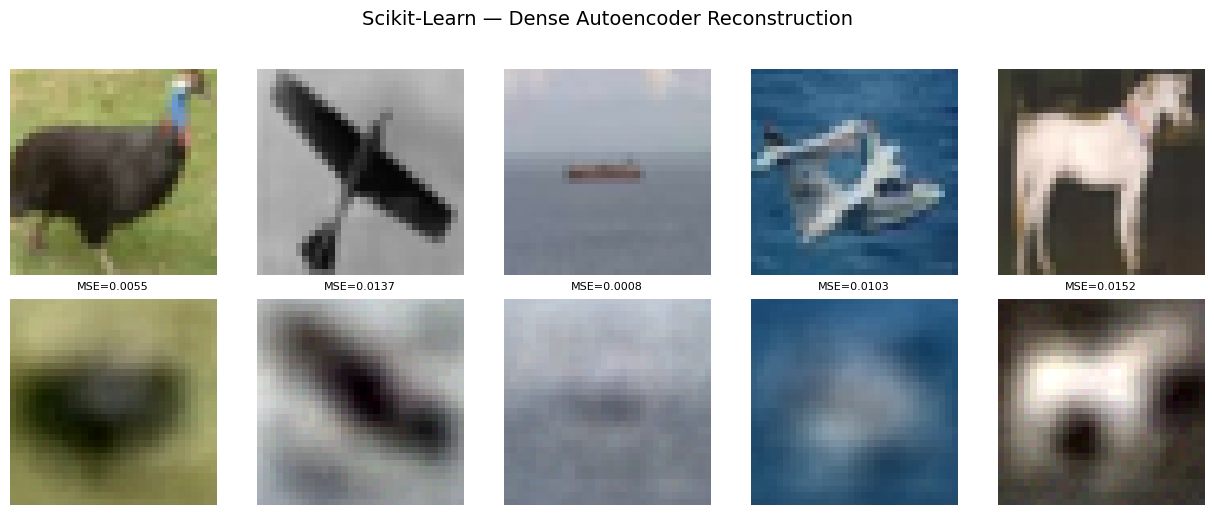

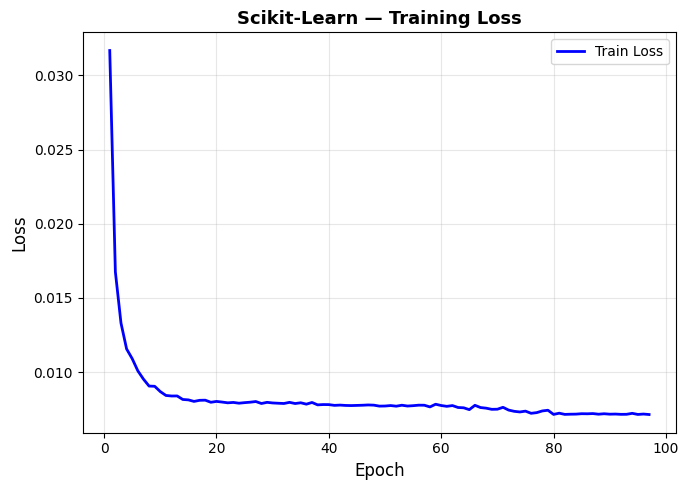


Train loss curve: 97 epochs
Final train loss: 0.007143
Best val R²:      0.776030


In [3]:
# Step 3: Visualizations

"""
Reconstruction grid (RGB) + training loss curve
MLPRegressor stores loss_curve_ (train MSE per epoch)
validation_scores_ is R² (not MSE) — different scale, plot train only
"""

print("=" * 60)
print("[3/8] Visualizations")
print("=" * 60)

# Reconstruction Grid
rng_viz = np.random.RandomState(RANDOM_STATE)
viz_idx = rng_viz.choice(len(X_test), 5, replace=False)

recon_dict = {128: X_test_recon[viz_idx]}
plot_reconstruction_grid(
    originals=X_test[viz_idx],
    reconstructions_dict=recon_dict,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Dense Autoencoder Reconstruction',
    row_label_prefix='dim',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/reconstruction_baseline.png'
)

# Training Loss Curve
# Train loss only — validation_scores_ is R² (different scale than MSE)
history = {
    'train_loss': baseline_ae.loss_curve_
}

plot_training_history(
    history=history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_baseline.png'
)

print(f"\nTrain loss curve: {len(baseline_ae.loss_curve_)} epochs")
print(f"Final train loss: {baseline_ae.loss_curve_[-1]:.6f}")
print(f"Best val R²:      {max(baseline_ae.validation_scores_):.6f}")